# 🧠 Megatron-LM core/transformer 目录架构详解
- NVIDIA Megatron-Core 的 Transformer 核心组件 — 可组合、GPU 优化的构建模块

## 📁 目录结构


In [ ]:
megatron/core/transformer/
├── __init__.py              # 包入口，导出核心 API
├── transformer_config.py   # TransformerConfig: 300+ 配置参数
├── transformer_block.py    # TransformerBlock: 多层堆叠 + Pipeline 并行
├── transformer_layer.py    # TransformerLayer: 单层 (Attention + MLP + Norm)
├── attention.py            # SelfAttention: QKV 投影 + 输出投影
├── dot_product_attention.py # 核心注意力计算 (Flash/Fused/Local/TE)
├── multi_latent_attention.py  # MLA (Multi-Latent Attention, DeepSeek 风格)
├── mlp.py                  # MLP: 标准/门控线性单元 (GLU/SwiGLU)
├── module.py               # MegatronModule: 所有组件的基类
├── spec_utils.py           # ModuleSpec: 插件式组件组合系统
├── enums.py                # 枚举: AttnBackend, AttnMaskType, LayerType 等
├── custom_layers/
│   └── transformer_engine.py  # Transformer Engine 适配层 (FP8/FP4)
├── moe/
│   ├── moe_layer.py        # MoELayer: 路由 + 专家计算
│   ├── router.py           # Top-K 路由逻辑
│   ├── experts.py          # GroupedMLP / SequentialMLP 专家实现
│   └── ...               # 其他 MoE 辅助模块
└── (其他辅助文件)
    ├── utils.py            # 工具函数
    ├── parallel_state.py   # 并行状态管理
    └── ...

## 🏗️ 组件层次架构


In [1]:
from IPython.display import Image

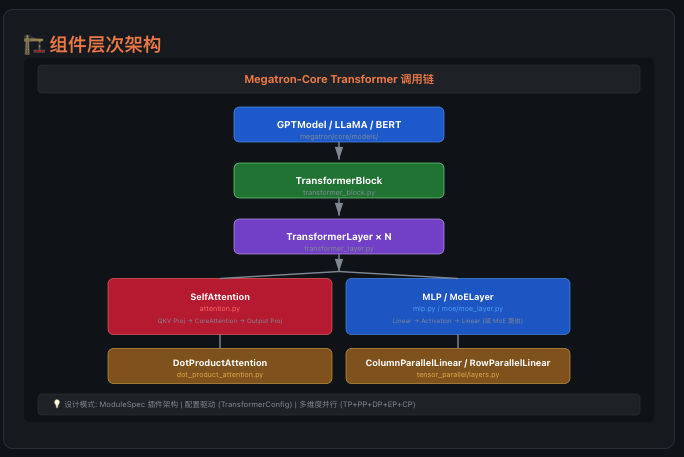

In [2]:
Image(filename='mg-core-transformer.png')

### ⚙️ transformer_config.py
TransformerConfig — 300+ 参数的配置中心

- 模型架构: num_layers, hidden_size, num_attention_heads
- 注意力后端: AttnBackend.auto/flash/fused/local/te
- MoE 配置: num_moe_experts, 负载均衡策略
- 高级特性: MLA, 多 token 预测, 滑动窗口
- 并行化: sequence_parallel, expert_model_parallel_size
- 精度: FP16 / BF16 / FP8 / FP4 支持

### 📦 transformer_block.py
TransformerBlock — 多层 Transformer 的容器

- 管理 layers = ModuleList([...]) 的堆叠
- 处理 Pipeline Parallelism: 按 stage 分配层数
- 支持 Virtual Pipeline Parallelism
- 支持不均匀层分配 (如 first stage 更多层)
- 集成 Activation Checkpointing (激活重计算)
- 前后处理: pre_process_block, post_process_block

### 🔧 transformer_layer.py
TransformerLayer — 单层的完整前向/反向

- 标准 Pre-Norm 结构: input_layernorm → Attention → MLP
- 残差连接: hidden_states = attention_out + residual
- 可选 Cross-Attention (Encoder-Decoder 模型)
- Dropout + Bias-Dropout-Add 融合优化
- 支持 Rotary Position Embedding (RoPE)
- TransformerLayerSubmodules 定义组件规范

### 👁️ attention.py
SelfAttention — 注意力模块的封装

- linear_qkv: QKV 联合投影 (Tensor Parallel)
- core_attention: 实际注意力计算 (可插拔后端)
- linear_proj: 输出投影 (Row Parallel)
- 可选 qk_layernorm: Query/Key 的 LayerNorm
- 支持 Grouped Query Attention (GQA)
- 自定义 backward_dw(): 权重梯度计算

### ⚡ dot_product_attention.py
DotProductAttention — 核心注意力内核

- FlashAttention (默认): 内存高效精确注意力
- FusedAttention: PyTorch 原生融合内核
- LocalAttention: 滑动窗口局部注意力
- TransformerEngine: NVIDIA TE 优化内核 (FP8)
- 自动选择最佳后端 (AttnBackend.auto)
- 支持因果掩码、ALiBi、RoPE 位置编码

### 🧮 mlp.py
MLP — 前馈网络实现

- 标准 MLP: Linear → Activation → Linear
- 门控线性单元 (GLU): SwiGLU, GeGLU, ReGLU
- linear_fc1 / linear_fc2: 张量并行线性层
- 支持 MoE 替换: MoELayer 替代标准 MLP
- 激活函数: GELU, SwiGLU, ReLU (通过 config 配置)
- 自定义 backward_dw() 优化权重梯度

### 🔌 spec_utils.py
ModuleSpec — 插件式架构核心

- 解耦"组件类型"与"具体实现"
- build_module(spec, config, ...) 动态构建
- 支持不同模型架构复用同一层结构
- GPT / LLaMA / BERT / T5 共享核心层
- 便于替换 Attention/MLP/Norm 实现
- 模型定义在 models/gpt/gpt_layer_specs.py

### 📋 module.py
MegatronModule — 所有组件的基类

- 继承自 torch.nn.Module
- 集成分布式检查点: sharded_state_dict()
- 支持 backward_dw() 自定义梯度
- FP8/FP4 精度管理接口
- Tensor Parallel 属性自动设置
- 推理缓存分配: allocate_inference_cache()

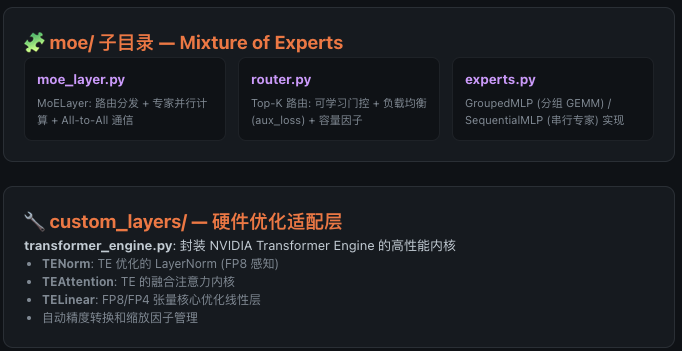

In [3]:
Image(filename='moe_custom.png')

### 🎯 核心设计模式


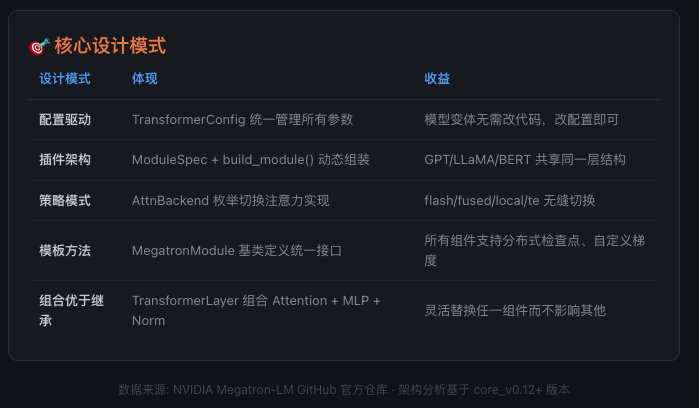

In [4]:
Image(filename='dz.png')

# 目录定位
- megatron/core/transformer/ 是 Megatron-Core 库的核心目录，包含了构建任意 Transformer 模型所需的所有基础组件。Megatron-Core 是一个可组合的 PyTorch 库，被 Megatron-LM、NVIDIA NeMo、Colossal-AI 等框架广泛使用。

# 核心文件详解
##  transformer_config.py — 配置中心
这是整个 Transformer 模块的单一事实来源（Single Source of Truth）。

In [ ]:
@dataclass
class TransformerConfig:
    num_layers: int = 0
    hidden_size: int = 0
    num_attention_heads: int = 0
    ffn_hidden_size: Optional[int] = None
    
    # 注意力后端选择
    attention_backend: AttnBackend = AttnBackend.auto
    
    # MoE 配置
    num_moe_experts: Optional[int] = None
    moe_router_load_balancing: str = "aux_loss"
    
    # 高级特性
    multi_latent_attention: bool = False  # DeepSeek MLA
    rotary_interleaved: bool = False
    
    # 并行化
    sequence_parallel: bool = False
    expert_model_parallel_size: int = 1

### 设计意义：
- 通过 TransformerConfig 统一管理 300+ 参数，使得 GPT、LLaMA、BERT、T5 等不同架构可以通过同一套底层组件 + 不同配置来构建，无需复制粘贴代码。

## transformer_block.py — 多层堆叠容器

TransformerBlock 负责管理多个 Transformer 层的堆叠，并处理与流水线并行（Pipeline Parallelism）的集成。


In [ ]:
class TransformerBlock(MegatronModule):
    def __init__(self, config, spec, num_layers, ...):
        # 计算当前 pipeline stage 需要构建的层数
        self.num_layers_per_pipeline_rank = get_num_layers_to_build(config)
        
        # 动态构建层
        self.layers = torch.nn.ModuleList([
            build_module(spec, config=i+1) 
            for i in range(self.num_layers_per_pipeline_rank)
        ])

### 关键能力：
- 流水线层分配：根据 parallel_state 自动计算当前 GPU 应该持有多少层
- 不均匀分配：支持 num_layers_in_first_pipeline_stage 让第一个 stage 持有- 更多层（常用于 embedding 较大的情况）
- 虚拟流水线并行：支持 interleaved pipeline scheduling
- 激活重计算：集成 checkpoint 机制，用计算换内存

## transformer_layer.py — 单层实现
这是最核心的文件，实现了标准的 Pre-Norm Transformer 层：

In [ ]:
Input → LayerNorm → SelfAttention → DropoutAdd → LayerNorm → MLP → DropoutAdd → Output
        ↑___________________________↑残差连接      ↑_____________________↑残差连接

In [ ]:
class TransformerLayer(MegatronModule):
    def forward(self, hidden_states, attention_mask, ...):
        # 1. Self-Attention 分支
        residual = hidden_states
        normed = self.input_layernorm(hidden_states)
        attention_output = self.self_attention(normed, attention_mask)
        hidden_states = self.self_attn_bda(attention_output, residual, dropout)
        
        # 2. MLP 分支
        residual = hidden_states
        normed = self.pre_mlp_layernorm(hidden_states)
        mlp_output = self.mlp(normed)
        hidden_states = self.mlp_bda(mlp_output, residual, dropout)
        
        return hidden_states

### 关键特性：
- Pre-Norm 结构：LayerNorm 在 Attention/MLP 之前（现代 LLM 标配）
- 可选 Cross-Attention：Encoder-Decoder 架构（如 T5）使用
- Rotary Position Embedding (RoPE) 集成
- Bias-Dropout-Add 融合：将三个操作融合为一个 CUDA kernel，减少内存访问

## attention.py — 注意力封装
SelfAttention 是高层次的注意力封装，负责 QKV 投影、输出投影和可选的归一化。

In [ ]:
class SelfAttention(MegatronModule):
    def __init__(self, config, submodules, layer_number):
        self.linear_qkv = submodules.linear_qkv      # ColumnParallelLinear
        self.core_attention = submodules.core_attention  # DotProductAttention
        self.linear_proj = submodules.linear_proj    # RowParallelLinear
        
        # 可选的 QK LayerNorm (用于稳定训练)
        if config.qk_layernorm:
            self.q_layernorm = submodules.q_layernorm
            self.k_layernorm = submodules.k_layernorm
    
    def forward(self, hidden_states, attention_mask):
        # 1. QKV 投影
        query, key, value = self._get_qkv(hidden_states)
        
        # 2. 可选 QK LayerNorm
        if self.config.qk_layernorm:
            query = self.q_layernorm(query)
            key = self.k_layernorm(key)
        
        # 3. 核心注意力计算
        context = self.core_attention(query, key, value, attention_mask)
        
        # 4. 输出投影
        output = self.linear_proj(context)
        return output

### 关键设计：
- QKV 联合投影：将 Query、Key、Value 的线性层合并为一个 ColumnParallelLinear，减少 kernel launch 开销
- Grouped Query Attention (GQA)：通过 num_query_groups 配置，让多个 Query head 共享一组 Key/Value head（LLaMA-2/3 使用）
- 自定义 backward_dw()：在 FP8 训练时，使用 Transformer Engine 的优化权重梯度计算

## dot_product_attention.py — 核心注意力内核
这是真正执行注意力计算的地方，支持多种后端：

| 后端                    | 适用场景      | 特点                 |
| --------------------- | --------- | ------------------ |
| **FlashAttention**    | 长序列训练     | 内存 $O(N)$，HBM 访问最少 |
| **FusedAttention**    | 短序列 / 推理  | PyTorch 原生融合内核     |
| **LocalAttention**    | 超长序列      | 滑动窗口，只计算局部         |
| **TransformerEngine** | H100/H200 | FP8 优化，TE 专用内核     |


In [ ]:
class DotProductAttention(MegatronModule):
    def forward(self, query, key, value, attention_mask):
        if self.config.attention_backend == AttnBackend.flash:
            return flash_attn_func(query, key, value, causal=True)
        elif self.config.attention_backend == AttnBackend.fused:
            return torch.nn.functional.scaled_dot_product_attention(...)
        # ...

### 自动选择：
- AttnBackend.auto 会根据硬件、序列长度、精度自动选择最优后端。

## mlp.py — 前馈网络

In [ ]:
class MLP(MegatronModule):
    def forward(self, hidden_states):
        # 第一个线性变换 (ColumnParallelLinear)
        intermediate = self.linear_fc1(hidden_states)
        
        # 门控线性单元 (如 SwiGLU)
        if self.config.gated_linear_unit:
            intermediate_gated = self.linear_fc1_gated(hidden_states)
            intermediate = self.activation_func(intermediate_gated) * intermediate
        else:
            intermediate = self.activation_func(intermediate)
        
        # 第二个线性变换 (RowParallelLinear)
        output = self.linear_fc2(intermediate)
        return output

### 关键特性：
- GLU 变体支持：SwiGLU（LLaMA 使用）、GeGLU、ReGLU 通过配置切换
- MoE 替换：在 MoE 模型中，MLP 被替换为 MoELayer，但接口保持一致
- 张量并行：fc1 是 ColumnParallel（按输出维度切分），fc2 是 RowParallel（按输入维度切分），两者配合实现高效并行

## spec_utils.py — 插件式架构核心
这是 Megatron-Core 最具创新性的设计之一。


In [ ]:
@dataclass
class ModuleSpec:
    module: type              # 类本身
    submodules: NamedTuple    # 子组件规范
    params: dict = field(default_factory=dict)  # 额外参数

def build_module(spec: ModuleSpec, **kwargs):
    # 递归构建子模块，然后构建父模块
    submodule_instances = {
        name: build_module(sub_spec, **kwargs) 
        for name, sub_spec in spec.submodules
    }
    return spec.module(**submodule_instances, **spec.params, **kwargs)

##### 使用示例（GPT 层的定义）：

In [ ]:
def get_gpt_layer_spec(config):
    return ModuleSpec(
        module=TransformerLayer,
        submodules=TransformerLayerSubmodules(
            self_attention=ModuleSpec(
                module=SelfAttention,
                submodules=SelfAttentionSubmodules(
                    linear_qkv=ColumnParallelLinear,
                    core_attention=DotProductAttention,
                    linear_proj=RowParallelLinear,
                )
            ),
            mlp=ModuleSpec(
                module=MLP,
                submodules=MLPSubmodules(
                    linear_fc1=ColumnParallelLinear,
                    linear_fc2=RowParallelLinear,
                )
            ),
            input_layernorm=RMSNorm,
            pre_mlp_layernorm=RMSNorm,
        )
    )

##### 设计意义：
- 解耦：
  - 模型架构定义（models/gpt/）与组件实现（transformer/）完全分离
- 复用：
  - LLaMA 和 GPT 共享同一个 TransformerLayer，只是 spec 不同（如 LLaMA 用 RMSNorm，GPT 用 LayerNorm）
- 扩展：
  - 添加新注意力机制（如 MLA）只需定义新的 ModuleSpec，无需修改现有代码
  
## module.py — 基类
所有 Transformer 组件的基类，提供：
- 分布式检查点：sharded_state_dict() 返回分片的状态字典
- 自定义梯度：backward_dw() 用于 FP8/TE 优化的权重更新
- 推理缓存：allocate_inference_cache() 为 KV Cache 分配内存
- 精度管理：自动处理 FP16/BF16/FP8/FP4 的转换


## enums.py — 枚举定义


In [ ]:
class AttnBackend(str, Enum):
    auto = "auto"
    flash = "flash"
    fused = "fused"
    local = "local"
    te = "transformer_engine"

class AttnMaskType(Enum):
    padding = 1      # 标准 padding mask
    causal = 2       # 因果掩码（Decoder）
    # ...

class LayerType(Enum):
    encoder = 1
    decoder = 2

## moe/ 子目录 — 混合专家系统
- moe_layer.py：MoE 层的主入口，包含路由逻辑和专家计算
- router.py：Top-K 门控网络，负责 token 到专家的分配，含负载均衡辅助损失
- experts.py：GroupedMLP（使用 Grouped GEMM 同时计算多个专家）和 SequentialMLP（串行计算）

## custom_layers/transformer_engine.py — 硬件适配层
封装 NVIDIA Transformer Engine 的优化组件：
- TENorm：FP8 感知的 LayerNorm
- TELinear：FP8/FP4 张量核心优化的线性层
- 自动管理缩放因子（scaling factor）和精度转换  

# 设计哲学总结

| 原则         | 体现                                           |
| ---------- | -------------------------------------------- |
| **配置驱动**   | 一个 `TransformerConfig` 定义所有行为                |
| **组合优于继承** | `TransformerLayer` 组合 Attention + MLP + Norm |
| **策略模式**   | `AttnBackend` 切换注意力实现                        |
| **依赖注入**   | `ModuleSpec` 将组件实现注入到架构中                     |
| **并行透明**   | 张量/流水线/序列并行对层内逻辑透明                           |
这套架构使得 Megatron-Core 能够用同一套代码支持从 1B 到 1T+ 参数、从单卡到万卡集群的 Transformer 训练，同时保持代码的可维护性和可扩展性